In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
import pandas as pd
from scipy.interpolate import CubicSpline  # Changed from interp1d
import glob
import os

In [2]:
def calculate_max_range(data_array):
    """
    Calculates the maximum peak-to-peak range of a given 1D array or list.
    
    Parameters:
    data_array (array-like): The numerical data (e.g., length or velocity).
    
    Returns:
    float: The total range (maximum value - minimum value).
    """
    # Convert to a numpy array just in case a standard Python list is passed
    arr = np.asarray(data_array)
    
    # Calculate and return the difference between the absolute max and min
    return np.max(arr) - np.min(arr)

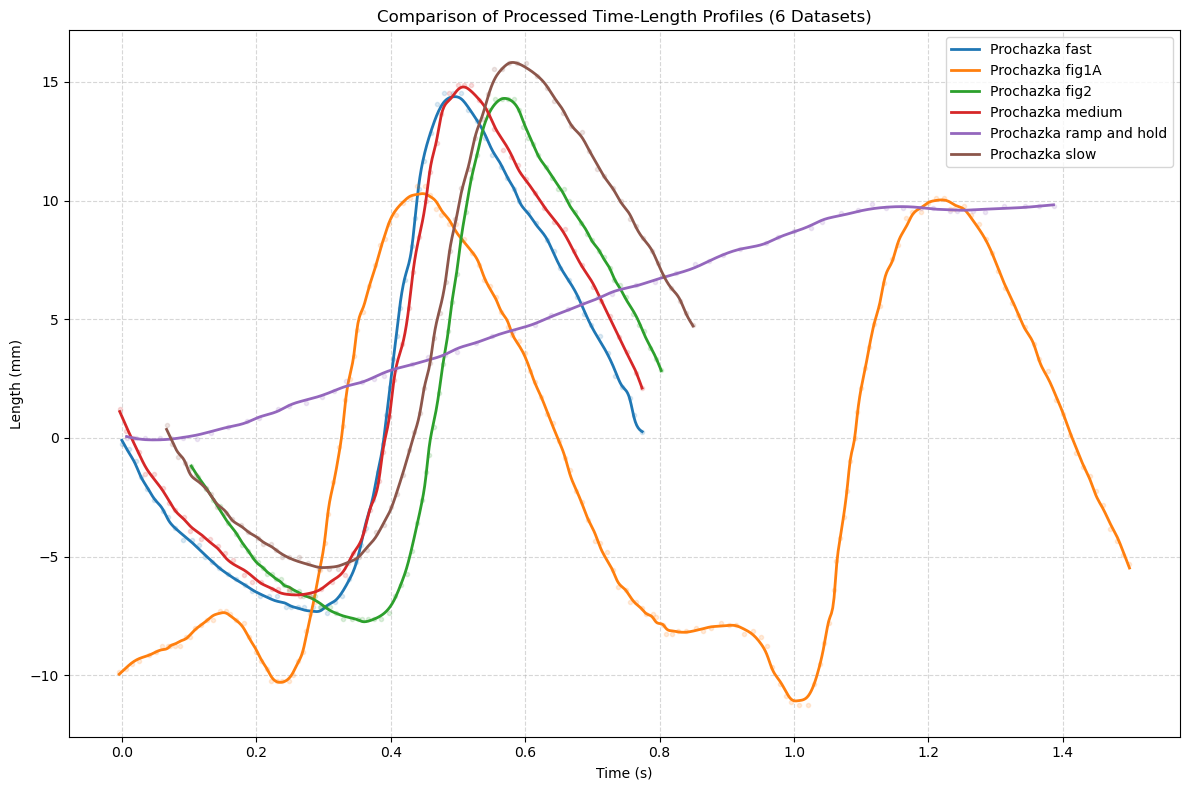

In [3]:
# 1. Define the list of your 6 files
file_names = [
    'Prochazka fast.csv',
    'Prochazka fig1A.csv',  # Replace with your actual file names
    'Prochazka fig2.csv', 
    'Prochazka medium.csv',
    'Prochazka ramp and hold.csv',
    'Prochazka slow.csv'
]

# Dictionary to hold the processed data in memory without saving files
processed_data = {}

# Set up a plot to visualize all 6 datasets together
plt.figure(figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# 2. Loop through each file and apply the processing
for i, file_path in enumerate(file_names):
    try:
        df = pd.read_csv(file_path, header=None)
        time = df[0].values
        length = df[1].values
        
        # 1. Light pre-smooth just to remove raw digitizer noise
        smooth_length = savgol_filter(length, window_length=13, polyorder=3)
        
        # 2. Use CubicSpline instead of interp1d
        # bc=type='natural' ensures smooth behavior at the boundaries
        cs = CubicSpline(time, smooth_length, bc_type='natural')
        
        # 3. Generate your dense 1000-point grid
        time_dense = np.linspace(time.min(), time.max(), 750)
        length_interpolated = cs(time_dense)

        # 4. FIXED: Get the exact, analytical mathematical derivative 
        # This completely avoids the noise spikes of np.gradient
        cs_derivative = cs.derivative()
        velocity = cs_derivative(time_dense)
        
        # 5. Optional: A very light smooth on velocity if your raw data was incredibly noisy
        velocity = savgol_filter(velocity, window_length=111, polyorder=2)

        # Firing Rate
        firing_rate = 4.3 * (np.sign(velocity) * np.abs(velocity)**0.6) + 2 * length_interpolated + 82
        
        # Derive a clean name from the filename for tracking
        dataset_name = file_path.replace('.csv', '').replace('_', ' ')
        
        # Store the numpy arrays in our dictionary
        processed_data[dataset_name] = {
            'time': time_dense,
            'length': length_interpolated,
            'velocity': velocity,
            'firing rate': firing_rate
        }
        
        # Plot the smooth curve for this dataset
        plt.plot(time_dense, length_interpolated, label=dataset_name, color=colors[i % len(colors)], linewidth=2)
        # Optional: plot original points faintly behind the curves
        plt.plot(time, length, 'o', color=colors[i % len(colors)], alpha=0.15, markersize=3)
        
    except FileNotFoundError:
        print(f"Warning: Could not find file '{file_path}'. Skipping.")
    except Exception as e:
        print(f"Error processing '{file_path}': {e}")

# 3. Finalize and display the combined plot
plt.xlabel('Time (s)')
plt.ylabel('Length (mm)')
plt.title('Comparison of Processed Time-Length Profiles (6 Datasets)')
plt.legend(frameon=True, loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- How to access the data later in your script ---
# Example: To grab the array for 'Prochazka fast' later on, you would write:
# fast_time = processed_data['Prochazka fast']['time']
# fast_length = processed_data['Prochazka fast']['length']

Text(0.5, 0, 'time (s)')

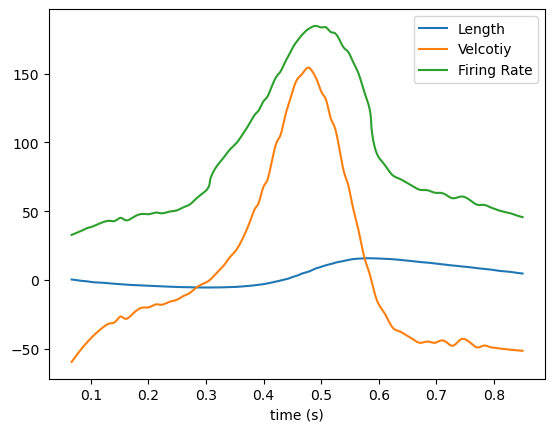

In [4]:
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['length'], label = "Length")
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['velocity'], label = "Velcotiy")
plt.plot(processed_data['Prochazka slow']['time'], processed_data['Prochazka slow']['firing rate'], label = "Firing Rate")
plt.legend()
plt.xlabel("time (s)")

In [5]:
print("Max Speed Slow: ",max(processed_data['Prochazka slow']['velocity']))
print("Max Speed Medium: ",max(processed_data['Prochazka medium']['velocity']))
print("Max Speed Fast: ",max(processed_data['Prochazka fast']['velocity']))

print("\nMax firing rate Slow: ",max(processed_data['Prochazka slow']['firing rate']))
print("Max firing rate Medium: ",max(processed_data['Prochazka medium']['firing rate']))
print("Max firing rate Fast: ",max(processed_data['Prochazka fast']['firing rate']))

Max Speed Slow:  154.3435656116728
Max Speed Medium:  183.17007754986693
Max Speed Fast:  206.4747251166197

Max firing rate Slow:  184.66314762035972
Max firing rate Medium:  192.7133881357787
Max firing rate Fast:  200.12644595593162


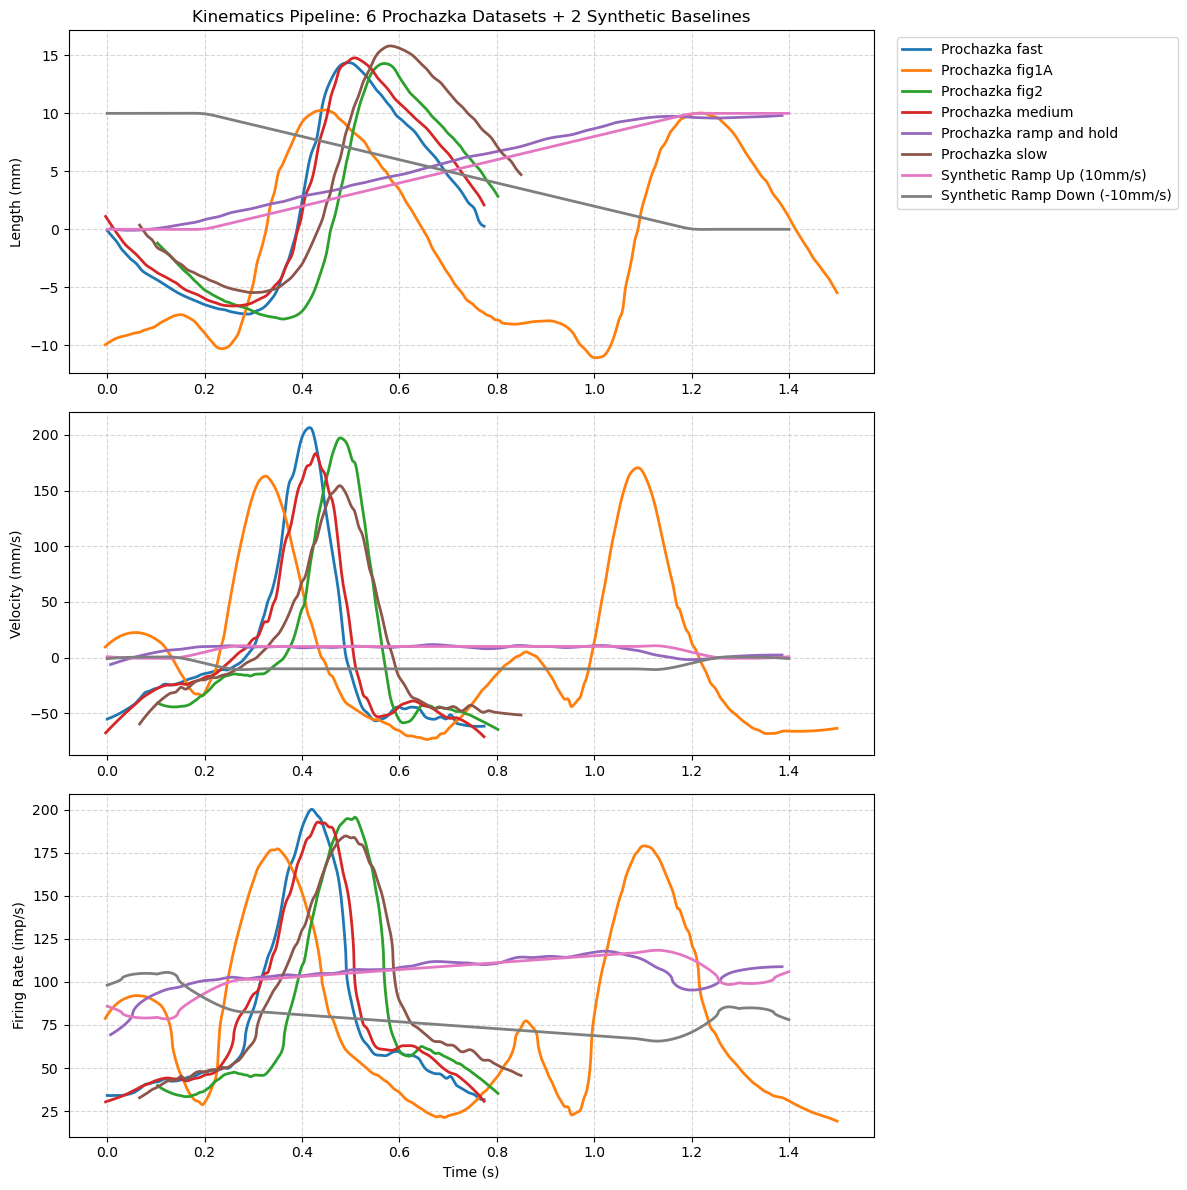

In [6]:
file_names = [
    'Prochazka fast.csv',
    'Prochazka fig1A.csv',
    'Prochazka fig2.csv',
    'Prochazka medium.csv',
    'Prochazka ramp and hold.csv',
    'Prochazka slow.csv'
]

# 1. Gather all raw data (Real + Synthetic) into a single dictionary
all_raw_data = {}

# --- Load Real CSV Data ---
for file_path in file_names:
    try:
        df = pd.read_csv(file_path, header=None)
        dataset_name = file_path.replace('.csv', '').replace('_', ' ')
        all_raw_data[dataset_name] = {
            'time': df[0].values,
            'length': df[1].values
        }
    except FileNotFoundError:
        print(f"Warning: Could not find file '{file_path}'. Skipping.")
    except Exception as e:
        print(f"Error processing '{file_path}': {e}")

# --- Generate Synthetic Data ---
t_synth = np.linspace(0, 1.4, 1400)

# Ramp Up: 0 to 10mm (0.2s hold, 1s ramp, 0.2s hold)
l_up_raw = np.piecewise(
    t_synth, 
    [t_synth < 0.2, (t_synth >= 0.2) & (t_synth <= 1.2), t_synth > 1.2], 
    [0, lambda t: 10 * (t - 0.2), 10]
)

# Ramp Down: 10 to 0mm (0.2s hold, 1s ramp, 0.2s hold)
l_down_raw = np.piecewise(
    t_synth, 
    [t_synth < 0.2, (t_synth >= 0.2) & (t_synth <= 1.2), t_synth > 1.2], 
    [10, lambda t: 10 - 10 * (t - 0.2), 0]
)

# Soften the sharp mathematical corners of the synthetic data to simulate physical movement
all_raw_data['Synthetic Ramp Up (10mm/s)'] = {
    'time': t_synth,
    'length': savgol_filter(l_up_raw, window_length=81, polyorder=3)
}
all_raw_data['Synthetic Ramp Down (-10mm/s)'] = {
    'time': t_synth,
    'length': savgol_filter(l_down_raw, window_length=81, polyorder=3)
}

# 2. Process all 8 datasets through the single pipeline
processed_data = {}

# Set up a 3-panel plot layout
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
colors = plt.cm.tab10.colors  # 10 distinct colors for the 8 lines

for i, (name, data) in enumerate(all_raw_data.items()):
    time = data['time']
    length = data['length']
    
    # Pre-smooth length
    smooth_length = savgol_filter(length, window_length=13, polyorder=3)
    
    # Cubic Spline Interpolation
    cs = CubicSpline(time, smooth_length, bc_type='natural')
    time_dense = np.linspace(time.min(), time.max(), 750)
    length_interpolated = cs(time_dense)

    # Analytical Derivative for Velocity
    cs_derivative = cs.derivative()
    velocity = cs_derivative(time_dense)
    
    # Smooth Velocity (Wide window to fix the noise issue from earlier)
    velocity = savgol_filter(velocity, window_length=111, polyorder=2)

    # Firing Rate Equation
    firing_rate = 4.3 * (np.sign(velocity) * np.abs(velocity)**0.6) + 2 * length_interpolated + 82
    
    # Store the processed arrays
    processed_data[name] = {
        'time': time_dense,
        'length': length_interpolated,
        'velocity': velocity,
        'firing rate': firing_rate
    }
    
    # Plotting
    c = colors[i % len(colors)]
    axes[0].plot(time_dense, length_interpolated, label=name, color=c, linewidth=2)
    axes[1].plot(time_dense, velocity, color=c, linewidth=2)
    axes[2].plot(time_dense, firing_rate, color=c, linewidth=2)

# 3. Finalize plot formatting
axes[0].set_ylabel('Length (mm)')
axes[0].set_title('Kinematics Pipeline: 6 Prochazka Datasets + 2 Synthetic Baselines')
# Move legend outside the plot so it doesn't cover data peaks
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].set_ylabel('Velocity (mm/s)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].set_ylabel('Firing Rate (imp/s)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
print("--- Maximum Length Ranges ---")
for name, data in processed_data.items():
    
    # Extract the length array for this specific dataset
    length_array = data['length']
    
    # Pass it through our function
    max_range = calculate_max_range(length_array)
    
    # Print the result formatted to 2 decimal places
    print(f"{name}: {max_range:.2f} mm")

--- Maximum Length Ranges ---
Prochazka fast: 21.69 mm
Prochazka fig1A: 21.37 mm
Prochazka fig2: 22.05 mm
Prochazka medium: 21.40 mm
Prochazka ramp and hold: 9.90 mm
Prochazka slow: 21.28 mm
Synthetic Ramp Up (10mm/s): 10.02 mm
Synthetic Ramp Down (-10mm/s): 10.02 mm


In [8]:
# ==========================================
# 2. THE SINUSOIDAL RETURN BRIDGE
# ==========================================
# Extract and zero the time of the fast data

t_fast = processed_data['Prochazka fast']['time']
l_fast = processed_data['Prochazka fast']['length']
t_fast = t_fast - t_fast.min()

L_start = l_fast[0]
L_end = l_fast[-1]
T_data = t_fast[-1]

# Generate the 0.5-second Sinusoidal Return Bridge
T_return = 0.5 
t_bridge = np.linspace(0, T_return, 100)[1:]
s_curve = (1 - np.cos(np.pi * (t_bridge / T_return))) / 2.0
l_bridge = L_end + (L_start - L_end) * s_curve
t_bridge_shifted = t_bridge + T_data

# Combine into a single cycle
t_cycle = np.concatenate([t_fast, t_bridge_shifted])
l_cycle = np.concatenate([l_fast, l_bridge])
T_cycle_total = t_cycle[-1]

l_cycle = l_cycle - np.min(l_cycle)

# Create the periodic spline function
cs_cycle = CubicSpline(t_cycle, l_cycle, bc_type='periodic')

def get_continuous_setpoint(t):
    t_wrapped = t % T_cycle_total
    return cs_cycle(t_wrapped)


# ==========================================
# 3. THE ARDUINO EXPORT CODE
# ==========================================
NUM_POINTS = 200

# Create evenly spaced time points across exactly one full cycle
t_lut = np.linspace(0, T_cycle_total, NUM_POINTS, endpoint=False)
l_lut = get_continuous_setpoint(t_lut)

# Calculate the time interval between points (in milliseconds for the Arduino)
dt_ms = (T_cycle_total / NUM_POINTS) * 1000

# Format and print the output as C++ code
print("================ COPY TO ARDUINO ================\n")
print(f"const int NUM_LUT_POINTS = {NUM_POINTS};")
print(f"const float LUT_DT_MS = {dt_ms:.3f}; // Milliseconds per index")
print(f"const float CYCLE_DURATION_MS = {T_cycle_total * 1000:.3f};\n")

print("// Store in Flash memory to save SRAM")
print("const float PROGMEM length_profile[] = {")

lines = []
for i in range(0, len(l_lut), 10):
    chunk = l_lut[i:i+10]
    line = "    " + ", ".join([f"{val:.4f}" for val in chunk]) + ","
    lines.append(line)
    
lines[-1] = lines[-1][:-1] # Remove trailing comma
print("\n".join(lines))
print("};\n")
print("=================================================")

================ COPY TO ARDUINO ================

const int NUM_LUT_POINTS = 200;
const float LUT_DT_MS = 6.371; // Milliseconds per index
const float CYCLE_DURATION_MS = 1274.112;

// Store in Flash memory to save SRAM
const float PROGMEM length_profile[] = {
    7.2165, 6.8911, 6.5892, 6.2725, 5.8589, 5.4966, 5.2113, 4.9066, 4.6565, 4.4555,
    4.1594, 3.8174, 3.5937, 3.4255, 3.2717, 3.1247, 2.9726, 2.8024, 2.6241, 2.4549,
    2.2891, 2.1215, 1.9550, 1.8016, 1.6674, 1.5422, 1.4206, 1.3079, 1.2023, 1.0891,
    0.9673, 0.8587, 0.7656, 0.6791, 0.5954, 0.5145, 0.4480, 0.4085, 0.3648, 0.2752,
    0.1969, 0.1508, 0.0953, 0.0479, 0.0225, 0.0039, 0.0110, 0.1100, 0.2626, 0.3652,
    0.4900, 0.7000, 0.9797, 1.3036, 1.6756, 2.2107, 2.9580, 3.7498, 4.3644, 5.1464,
    6.0790, 7.0554, 8.5252, 10.0263, 11.5072, 12.9872, 14.0052, 14.6528, 15.7657, 17.4655,
    18.7229, 19.5209, 20.1288, 20.6577, 21.0974, 21.4126, 21.5965, 21.6759, 21.6910, 21.6307,
    21.4610, 21.2161, 20.9516, 20.6747, 20.3753, 

In [9]:
# ==========================================
# 2. THE SINUSOIDAL RETURN BRIDGE
# ==========================================
# Extract and zero the time of the fast data

t_fast = processed_data['Prochazka medium']['time']
l_fast = processed_data['Prochazka medium']['length']
t_fast = t_fast - t_fast.min()

L_start = l_fast[0]
L_end = l_fast[-1]
T_data = t_fast[-1]

# Generate the 0.5-second Sinusoidal Return Bridge
T_return = 0.5 
t_bridge = np.linspace(0, T_return, 100)[1:]
s_curve = (1 - np.cos(np.pi * (t_bridge / T_return))) / 2.0
l_bridge = L_end + (L_start - L_end) * s_curve
t_bridge_shifted = t_bridge + T_data

# Combine into a single cycle
t_cycle = np.concatenate([t_fast, t_bridge_shifted])
l_cycle = np.concatenate([l_fast, l_bridge])
T_cycle_total = t_cycle[-1]

l_cycle = l_cycle - np.min(l_cycle)

# Create the periodic spline function
cs_cycle = CubicSpline(t_cycle, l_cycle, bc_type='periodic')

def get_continuous_setpoint(t):
    t_wrapped = t % T_cycle_total
    return cs_cycle(t_wrapped)


# ==========================================
# 3. THE ARDUINO EXPORT CODE
# ==========================================
NUM_POINTS = 200

# Create evenly spaced time points across exactly one full cycle
t_lut = np.linspace(0, T_cycle_total, NUM_POINTS, endpoint=False)
l_lut = get_continuous_setpoint(t_lut)

# Calculate the time interval between points (in milliseconds for the Arduino)
dt_ms = (T_cycle_total / NUM_POINTS) * 1000

# Format and print the output as C++ code
print("================ COPY TO ARDUINO ================\n")
print(f"const int NUM_LUT_POINTS = {NUM_POINTS};")
print(f"const float LUT_DT_MS = {dt_ms:.3f}; // Milliseconds per index")
print(f"const float CYCLE_DURATION_MS = {T_cycle_total * 1000:.3f};\n")

print("// Store in Flash memory to save SRAM")
print("const float PROGMEM length_profile[] = {")

lines = []
for i in range(0, len(l_lut), 10):
    chunk = l_lut[i:i+10]
    line = "    " + ", ".join([f"{val:.4f}" for val in chunk]) + ","
    lines.append(line)
    
lines[-1] = lines[-1][:-1] # Remove trailing comma
print("\n".join(lines))
print("};\n")
print("=================================================")

================ COPY TO ARDUINO ================

const int NUM_LUT_POINTS = 200;
const float LUT_DT_MS = 6.385; // Milliseconds per index
const float CYCLE_DURATION_MS = 1277.070;

// Store in Flash memory to save SRAM
const float PROGMEM length_profile[] = {
    7.7251, 7.3101, 6.9030, 6.5093, 6.1287, 5.7494, 5.3974, 5.1190, 4.8852, 4.6537,
    4.4011, 4.1147, 3.8087, 3.5357, 3.3469, 3.1803, 2.9803, 2.8048, 2.6719, 2.5404,
    2.3828, 2.2260, 2.0892, 1.9258, 1.7063, 1.5036, 1.3535, 1.2413, 1.1461, 1.0429,
    0.9140, 0.7659, 0.6132, 0.4824, 0.3895, 0.3099, 0.2140, 0.1175, 0.0568, 0.0250,
    0.0077, 0.0001, 0.0056, 0.0260, 0.0589, 0.1014, 0.1620, 0.2573, 0.3921, 0.5371,
    0.6608, 0.7848, 0.9687, 1.2650, 1.6173, 1.9069, 2.2018, 2.7017, 3.4193, 3.9291,
    4.4725, 5.6718, 6.7250, 7.7359, 9.1919, 10.0205, 10.6434, 11.6266, 13.1130, 14.4007,
    15.2839, 16.2182, 17.5426, 18.5394, 19.3212, 20.2750, 20.7002, 20.8827, 21.1160, 21.3202,
    21.3996, 21.3445, 21.1999, 21.0193, 20.8164, 20

In [10]:
# ==========================================
# 2. THE SINUSOIDAL RETURN BRIDGE
# ==========================================
# Extract and zero the time of the fast data

t_fast = processed_data['Prochazka slow']['time']
l_fast = processed_data['Prochazka slow']['length']
t_fast = t_fast - t_fast.min()

L_start = l_fast[0]
L_end = l_fast[-1]
T_data = t_fast[-1]

# Generate the 0.5-second Sinusoidal Return Bridge
T_return = 0.5 
t_bridge = np.linspace(0, T_return, 100)[1:]
s_curve = (1 - np.cos(np.pi * (t_bridge / T_return))) / 2.0
l_bridge = L_end + (L_start - L_end) * s_curve
t_bridge_shifted = t_bridge + T_data

# Combine into a single cycle
t_cycle = np.concatenate([t_fast, t_bridge_shifted])
l_cycle = np.concatenate([l_fast, l_bridge])
T_cycle_total = t_cycle[-1]

l_cycle = l_cycle - np.min(l_cycle)

# Create the periodic spline function
cs_cycle = CubicSpline(t_cycle, l_cycle, bc_type='periodic')

def get_continuous_setpoint(t):
    t_wrapped = t % T_cycle_total
    return cs_cycle(t_wrapped)


# ==========================================
# 3. THE ARDUINO EXPORT CODE
# ==========================================
NUM_POINTS = 200

# Create evenly spaced time points across exactly one full cycle
t_lut = np.linspace(0, T_cycle_total, NUM_POINTS, endpoint=False)
l_lut = get_continuous_setpoint(t_lut)

# Calculate the time interval between points (in milliseconds for the Arduino)
dt_ms = (T_cycle_total / NUM_POINTS) * 1000

# Format and print the output as C++ code
print("================ COPY TO ARDUINO ================\n")
print(f"const int NUM_LUT_POINTS = {NUM_POINTS};")
print(f"const float LUT_DT_MS = {dt_ms:.3f}; // Milliseconds per index")
print(f"const float CYCLE_DURATION_MS = {T_cycle_total * 1000:.3f};\n")

print("// Store in Flash memory to save SRAM")
print("const float PROGMEM length_profile[] = {")

lines = []
for i in range(0, len(l_lut), 10):
    chunk = l_lut[i:i+10]
    line = "    " + ", ".join([f"{val:.4f}" for val in chunk]) + ","
    lines.append(line)
    
lines[-1] = lines[-1][:-1] # Remove trailing comma
print("\n".join(lines))
print("};\n")
print("=================================================")

================ COPY TO ARDUINO ================

const int NUM_LUT_POINTS = 200;
const float LUT_DT_MS = 6.416; // Milliseconds per index
const float CYCLE_DURATION_MS = 1283.299;

// Store in Flash memory to save SRAM
const float PROGMEM length_profile[] = {
    5.8222, 5.4354, 5.0475, 4.7719, 4.5490, 4.1180, 3.8111, 3.6713, 3.5283, 3.3454,
    3.1128, 2.8457, 2.6278, 2.4806, 2.2907, 2.0397, 1.8799, 1.7761, 1.6414, 1.4941,
    1.3813, 1.2708, 1.1287, 1.0109, 0.9185, 0.7935, 0.6581, 0.5408, 0.4428, 0.3607,
    0.2910, 0.2307, 0.1758, 0.1208, 0.0653, 0.0210, 0.0010, 0.0037, 0.0156, 0.0349,
    0.0750, 0.1404, 0.2129, 0.2825, 0.3780, 0.5364, 0.7490, 0.9538, 1.1614, 1.4317,
    1.7637, 2.0930, 2.4645, 2.9628, 3.5238, 4.1061, 4.7223, 5.3633, 5.9697, 6.7969,
    7.7898, 8.5412, 9.7607, 10.6447, 11.3974, 12.5209, 13.7423, 14.5609, 15.4993, 16.2711,
    16.9154, 17.7343, 18.4340, 18.9299, 19.5119, 20.1096, 20.5570, 20.8484, 21.0525, 21.2080,
    21.2779, 21.2613, 21.1948, 21.0989, 20.9857, 

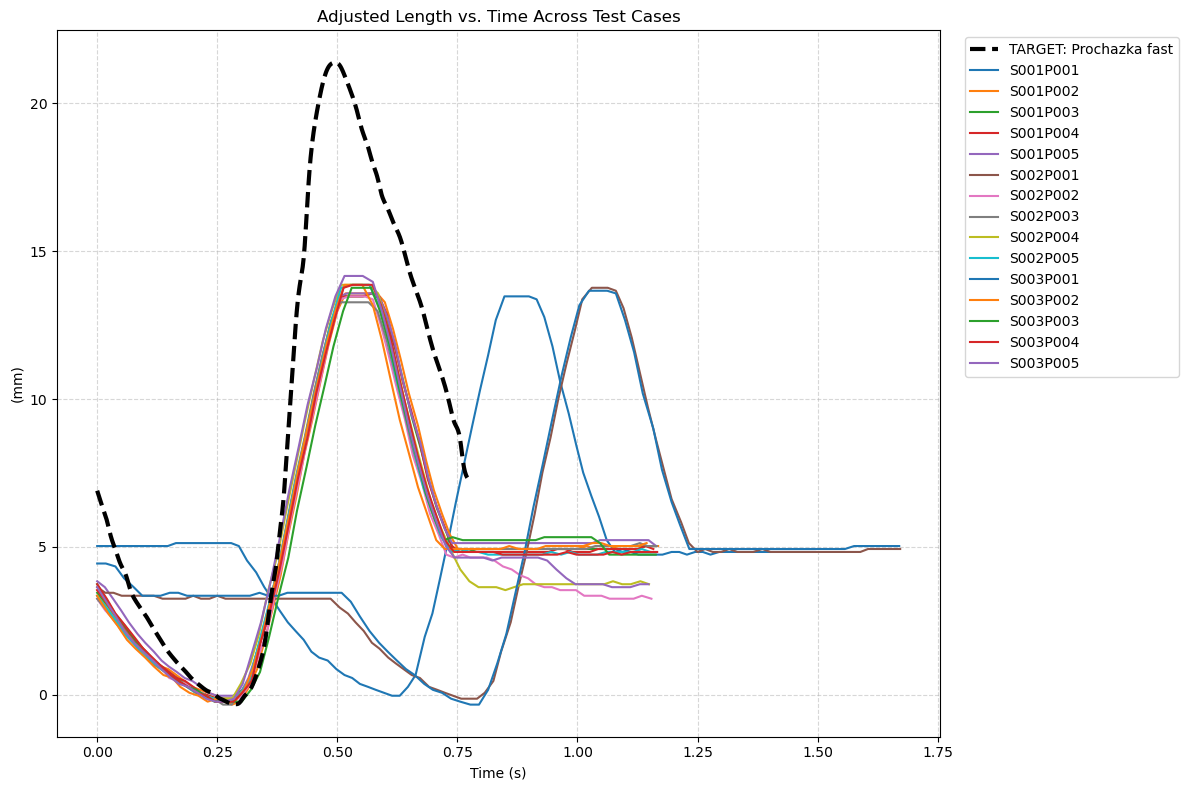

In [11]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)

# Loop through S values 1 to 3
for s in range(1, 4):
    # Loop through P values 1 to 5
    for p in range(1, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0]
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = 187 - df['Length (mm)']
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.ylabel('(mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()

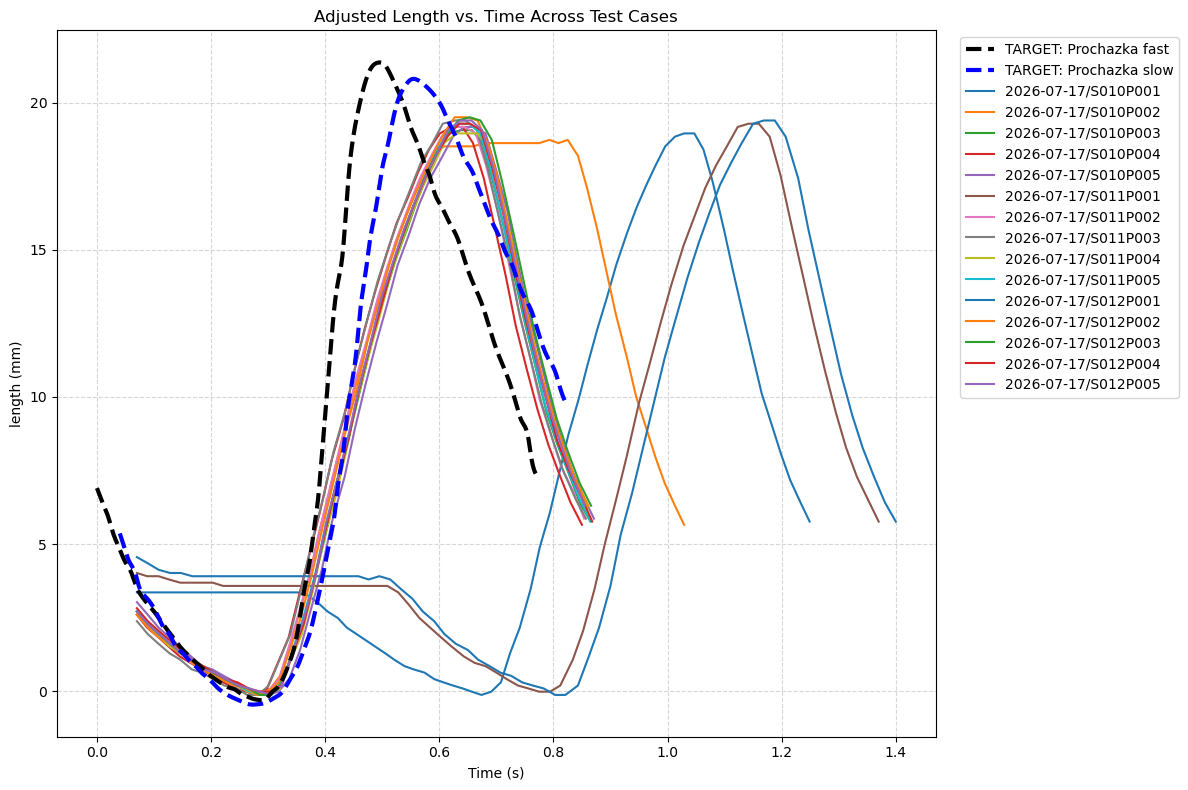

In [12]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

t_pro1 = processed_data['Prochazka slow']['time']
l_pro1 = processed_data['Prochazka slow']['length']

# Normalize time to start at 0
t_pro_norm1 = t_pro1 - t_pro1.min()+0.04

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj1 = l_pro1 + 5 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)
plt.plot(t_pro_norm1, l_pro_adj1, color='blue', linewidth=3, linestyle='--', label='TARGET: Prochazka slow', zorder=10)


# Loop through S values 1 to 3
for s in range(10, 13):
    # Loop through P values 1 to 5
    for p in range(1, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"2026-07-17/S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0] + 0.07
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = (187.5 - df['Length (mm)'])*1.1
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.ylabel('length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()

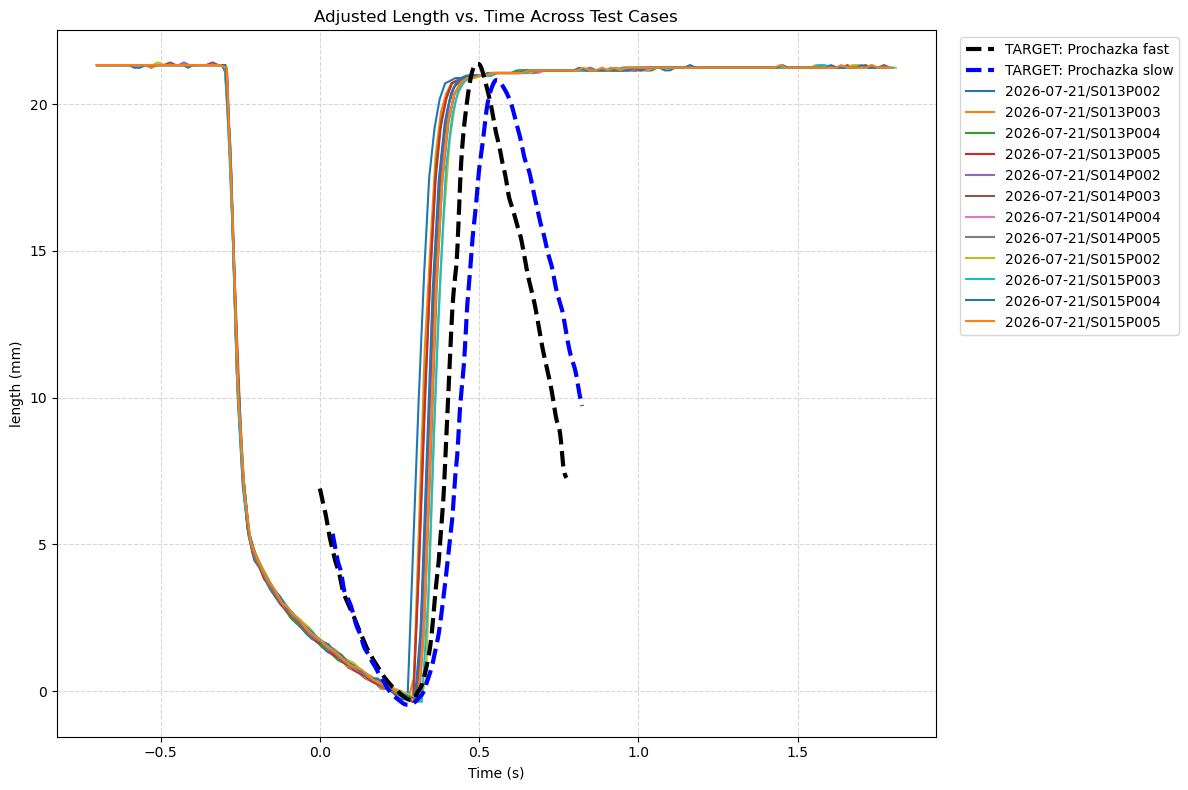

In [13]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

t_pro1 = processed_data['Prochazka slow']['time']
l_pro1 = processed_data['Prochazka slow']['length']

# Normalize time to start at 0
t_pro_norm1 = t_pro1 - t_pro1.min()+0.04

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj1 = l_pro1 + 5 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)
plt.plot(t_pro_norm1, l_pro_adj1, color='blue', linewidth=3, linestyle='--', label='TARGET: Prochazka slow', zorder=10)


# Loop through S values 1 to 3
for s in range(13, 16):
    # Loop through P values 1 to 5
    for p in range(2, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"2026-07-21/S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0] - 0.7
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = (189 - df['Length (mm)']) *0.9
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.ylabel('length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()

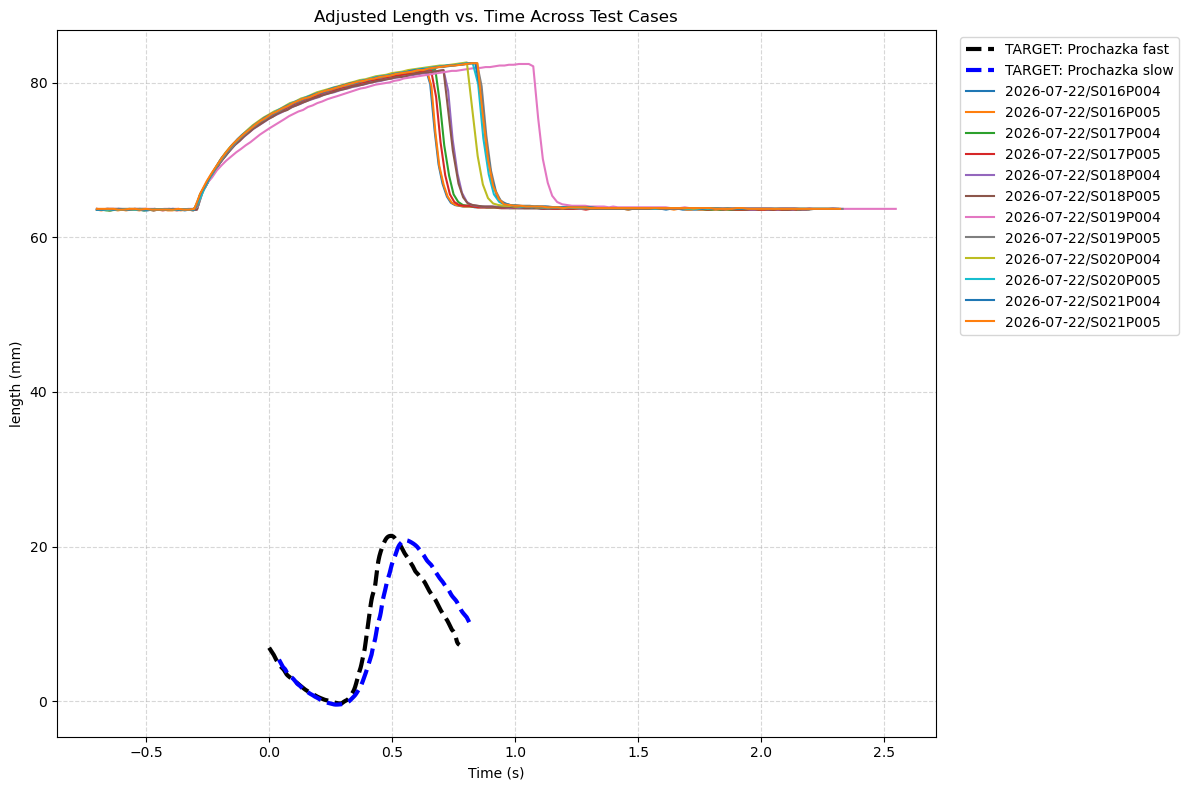

In [14]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

t_pro1 = processed_data['Prochazka slow']['time']
l_pro1 = processed_data['Prochazka slow']['length']

# Normalize time to start at 0
t_pro_norm1 = t_pro1 - t_pro1.min()+0.04

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj1 = l_pro1 + 5 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)
plt.plot(t_pro_norm1, l_pro_adj1, color='blue', linewidth=3, linestyle='--', label='TARGET: Prochazka slow', zorder=10)


# Loop through S values 1 to 3
for s in range(16, 22):
    # Loop through P values 1 to 5
    for p in range(4, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"2026-07-22/S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0] - 0.7
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = df['Length (mm)'] - 101.6
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.ylabel('length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()

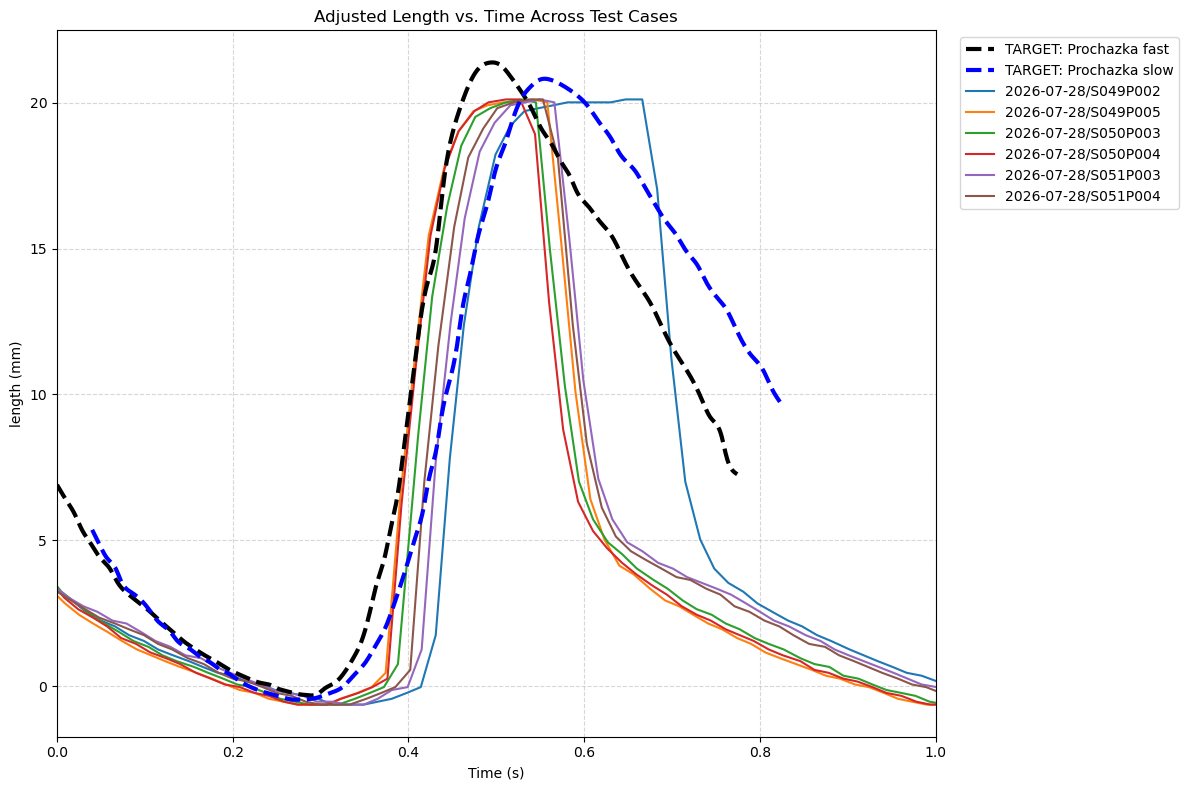

In [127]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

t_pro1 = processed_data['Prochazka slow']['time']
l_pro1 = processed_data['Prochazka slow']['length']

# Normalize time to start at 0
t_pro_norm1 = t_pro1 - t_pro1.min()+0.04

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj1 = l_pro1 + 5 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)
plt.plot(t_pro_norm1, l_pro_adj1, color='blue', linewidth=3, linestyle='--', label='TARGET: Prochazka slow', zorder=10)


# Loop through S values 1 to 3
for s in range(49, 53):
    # Loop through P values 1 to 5
    for p in range(1, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"2026-07-28/S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0] 
            
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = df['Length (mm)']-4
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.xlim(0,1);
plt.ylabel('length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()

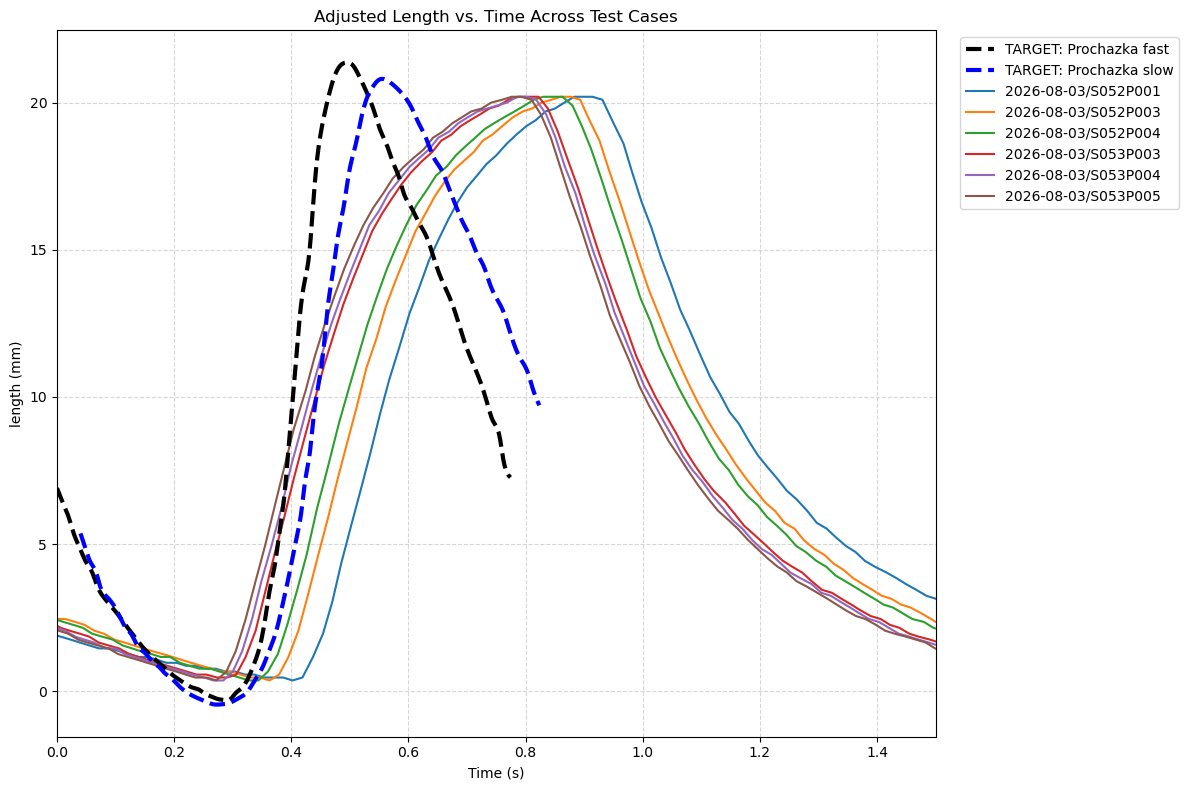

In [145]:
plt.figure(figsize=(12, 8))

t_pro = processed_data['Prochazka fast']['time']
l_pro = processed_data['Prochazka fast']['length']

# Normalize time to start at 0
t_pro_norm = t_pro - t_pro.min()

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj = l_pro + 7 #l_pro[0] - l_pro

t_pro1 = processed_data['Prochazka slow']['time']
l_pro1 = processed_data['Prochazka slow']['length']

# Normalize time to start at 0
t_pro_norm1 = t_pro1 - t_pro1.min()+0.04

# Adjust length to match the experimental data transformation
# Subtracting the array from its initial value sets the start to 0 and inverts the curve
l_pro_adj1 = l_pro1 + 5 #l_pro[0] - l_pro

# Plot as a thick, dashed black line to serve as the baseline reference
plt.plot(t_pro_norm, l_pro_adj, color='black', linewidth=3, linestyle='--', label='TARGET: Prochazka fast', zorder=10)
plt.plot(t_pro_norm1, l_pro_adj1, color='blue', linewidth=3, linestyle='--', label='TARGET: Prochazka slow', zorder=10)


# Loop through S values 1 to 3
for s in range(49, 54):
    # Loop through P values 1 to 5
    for p in range(1, 6):
        
        # Format the filename with 3 digits and leading zeros (e.g., "S001P001.TXT")
        file_name = f"2026-08-03/S{s:03d}P{p:03d}.TXT"
        
        # Check if the file exists in the current folder before processing
        if os.path.exists(file_name):
            try:
                # Load the data, skipping spaces after commas
                df = pd.read_csv(file_name, skipinitialspace=True)
                
                # Extract Time and normalize so it starts exactly at 0
                time = df['t (s)']/1000
                time_normalized = time - time.iloc[0] -1.6
            
                
                # Extract Length, set 182 to 0, and invert the direction
                adjusted_length = df['Length (mm)']-4
                
                # Plot this specific dataset
                plt.plot(time_normalized, adjusted_length, linestyle='-', linewidth=1.5, label=file_name.replace('.TXT', ''))
                
            except KeyError as e:
                print(f"Warning: Column not found in {file_name}. Error: {e}")
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        else:
            pass

# Finalize the plot formatting
plt.title('Adjusted Length vs. Time Across Test Cases')
plt.xlabel('Time (s)')
plt.xlim(0,1.5);
plt.ylabel('length (mm)')
plt.grid(True, linestyle='--', alpha=0.5)

# Place the legend outside the plot so it doesn't cover your data lines
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', ncol=1, frameon=True)

# Adjust layout to make room for the external legend
plt.tight_layout()

# Display the final combined plot
plt.show()